In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import Cityscapes
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt

# Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4  # Monte a 8 si la VRAM le permet
EPOCHS = 5
LEARNING_RATE = 0.001
# On reduit la taille pour eviter les erreurs "Out Of Memory" sur le GPU
# Cityscapes est nativement en 1024x2048, on passe en 256x512
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 512
NUM_CLASSES = 19  # Les 19 classes standards de Cityscapes

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [2]:
# Mapping officiel Cityscapes : ID brut -> ID d'entraînement (0 à 18)
valid_classes = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33]
class_map = dict(zip(valid_classes, range(19)))

def map_cityscapes_labels(mask):
    # On convertit le masque en numpy array
    mask = np.array(mask)
    mask_mapped = np.full(mask.shape, 255, dtype=np.uint8) # 255 = Ignore index
    for raw_id, train_id in class_map.items():
        mask_mapped[mask == raw_id] = train_id
    return mask_mapped

In [3]:
# Transformations pour l'entraînement
train_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.HorizontalFlip(p=0.5), # Data augmentation de base
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # Standard ImageNet
    ToTensorV2(),
])

# Transformations pour la validation/test (pas de data augmentation)
val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
from pathlib import Path

# Chemins explicites vers les dossiers Cityscapes utilises
LEFTIMG8BIT_DIR = Path("/home/demarsac/Documents/coding/Unet/cityscapes/leftImg8bit")
GTFINE_DIR = Path("/home/demarsac/Documents/coding/Unet/cityscapes/gtFine_trainvaltest/gtFine")

def prepare_cityscapes_root(left_dir, gt_dir):
    """Construit un root compatible torchvision.datasets.Cityscapes a partir de chemins explicites."""
    left_dir = Path(left_dir).expanduser().resolve()
    gt_dir = Path(gt_dir).expanduser().resolve()

    if not left_dir.exists() or not gt_dir.exists():
        raise RuntimeError(
            f"Dossiers Cityscapes introuvables. leftImg8bit={left_dir}, gtFine={gt_dir}"
        )

    # On cree un dossier de pont avec des liens symboliques pour respecter la structure attendue
    bridge_root = left_dir.parent / ".torchvision_cityscapes"
    bridge_root.mkdir(exist_ok=True)

    for name, target in {"leftImg8bit": left_dir, "gtFine": gt_dir}.items():
        link = bridge_root / name
        if link.exists() or link.is_symlink():
            if link.resolve() != target.resolve():
                if link.is_symlink():
                    link.unlink()
                    os.symlink(target, link, target_is_directory=True)
                else:
                    raise RuntimeError(
                        f"{link} existe deja et n'est pas un lien symbolique vers {target}."
                    )
        else:
            os.symlink(target, link, target_is_directory=True)

    return str(bridge_root)

ROOT_DIR = prepare_cityscapes_root(LEFTIMG8BIT_DIR, GTFINE_DIR)

# Verification explicite des splits utilises
for required_split in ["train", "val"]:
    left_split_dir = Path(ROOT_DIR) / "leftImg8bit" / required_split
    gt_split_dir = Path(ROOT_DIR) / "gtFine" / required_split
    if not left_split_dir.exists() or not gt_split_dir.exists():
        raise RuntimeError(
            f"Split manquant: {required_split}. Attendu: {left_split_dir} et {gt_split_dir}"
        )

# Wrapper pour appliquer Albumentations sur le dataset torchvision
class CityscapesCustom(Cityscapes):
    def __init__(self, root, split, transform):
        super().__init__(root, split=split, mode='fine', target_type='semantic')
        self.custom_transform = transform

    def __getitem__(self, index):
        image, mask = super().__getitem__(index)
        # Application du mapping des 19 classes
        mask = map_cityscapes_labels(mask)
        # Application des transformations
        augmented = self.custom_transform(image=np.array(image), mask=mask)
        return augmented['image'], augmented['mask'].long()  # Le masque DOIT etre un LongTensor

train_dataset = CityscapesCustom(ROOT_DIR, split='train', transform=train_transform)
val_dataset = CityscapesCustom(ROOT_DIR, split='val', transform=val_transform)

NUM_WORKERS = max(1, min(8, os.cpu_count() or 4))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True,
    prefetch_factor=2,
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True,
    prefetch_factor=2,
    )

In [5]:
# Desactive torch.compile par defaut: sur certains environnements, Triton/Inductor echoue
# (erreur gcc/libcuda) meme avec un GPU NVIDIA fonctionnel.
USE_TORCH_COMPILE = False

model = smp.Unet(
    encoder_name="resnet34",        # Encodeur leger et performant
    encoder_weights="imagenet",     # Poids pre-entraines pour accelerer l'apprentissage
    in_channels=3,                    # RGB
    classes=NUM_CLASSES               # 19 classes en sortie
).to(DEVICE, memory_format=torch.channels_last)

if DEVICE == "cuda" and USE_TORCH_COMPILE:
    try:
        import torch._dynamo
        torch._dynamo.config.suppress_errors = True
        model = torch.compile(model, mode="max-autotune")
        print("torch.compile active")
    except Exception as e:
        print(f"torch.compile indisponible ({e}), entrainement sans compilation.")

# Fonction de perte : CrossEntropy avec ignorance de l'index 255
criterion = nn.CrossEntropyLoss(ignore_index=255)

if DEVICE == "cuda":
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, fused=True)
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [6]:
print(f"Debut de l'entrainement sur {DEVICE}...")

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # Phase de validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
            masks = masks.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Sauvegarde du modele
torch.save(model.state_dict(), "unet_cityscapes.pth")
print("Entrainement termine et modele sauvegarde !")

Debut de l'entrainement sur cuda...


/tmp/ipykernel_32479/51837739.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


Epoch 1/5 | Train Loss: 0.6454 | Val Loss: 0.6094
Epoch 2/5 | Train Loss: 0.4719 | Val Loss: 0.4383
Epoch 3/5 | Train Loss: 0.4173 | Val Loss: 0.4939
Epoch 4/5 | Train Loss: 0.3776 | Val Loss: 0.3988
Epoch 5/5 | Train Loss: 0.3501 | Val Loss: 0.3733
Entrainement termine et modele sauvegarde !


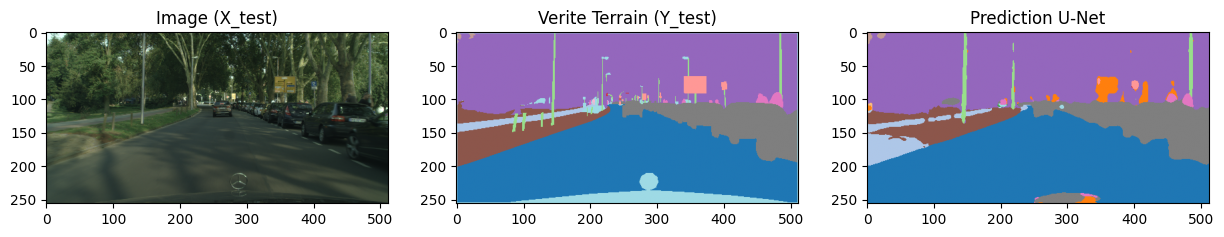

In [7]:
# Recuperer un batch de validation
model.eval()
images, masks = next(iter(val_loader))
images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)

with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
        predictions = model(images)
    # On prend la classe avec la plus haute probabilite pour chaque pixel (argmax)
    predictions = torch.argmax(predictions, dim=1).cpu().numpy()

# Visualisation de la premiere image du batch
img_display = images[0].cpu().permute(1, 2, 0).numpy()
# De-normalisation pour un bel affichage
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

mask_display = masks[0].cpu().numpy()
pred_display = predictions[0]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_display)
ax[0].set_title("Image (X_test)")
ax[1].imshow(mask_display, vmin=0, vmax=18, cmap='tab20')
ax[1].set_title("Verite Terrain (Y_test)")
ax[2].imshow(pred_display, vmin=0, vmax=18, cmap='tab20')
ax[2].set_title("Prediction U-Net")
plt.show()